# PA Prediction Engine

This notebook turns batting-order observations into plate-appearance forecasts. It separates the problem into two statistical pieces:

1. **How many starts will the player get?**
   We model starts as a beta-binomial process using observed starts and team games to date.

2. **How many PA does each start produce?**
   We fit a historical weighted regression for PA per start as a function of average batting-order slot and role size.

The final forecast combines uncertainty from both pieces with Monte Carlo sampling, producing median and interval estimates rather than a single point forecast.

In [1]:
from __future__ import annotations

import os
import unicodedata
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'batting-order-matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(Path('/tmp') / 'batting-order-cache'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import beta

In [2]:
TARGET_YEAR = '2026'
TRAIN_YEARS = list(range(2014, 2024))
FULL_SEASON_GAMES = 162
MIN_TRAIN_STARTS = 20
MIN_FORECAST_STARTS = 3
START_PRIOR_ALPHA = 2.0
START_PRIOR_BETA = 2.0
N_DRAWS = 20_000
MIN_PA_PER_START = 2.0
MAX_PA_PER_START = 6.5
RNG_SEED = 42


def find_data_root() -> Path:
    for candidate in [Path('../../data'), Path('../data'), Path('data')]:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find repository data directory from this working directory.')


DATA_ROOT = find_data_root()
SUMMARY_ROOT = DATA_ROOT / 'Aggregate' / 'Summaries'
YEARLY_STATS_ROOT = DATA_ROOT / 'Aggregate' / 'YearlyStats'
DATA_ROOT

PosixPath('../../data')

In [3]:
def strip_accents(text: object) -> str:
    text = '' if pd.isna(text) else str(text)
    text = unicodedata.normalize('NFD', text)
    return text.encode('ascii', 'ignore').decode('utf-8')


def player_name_key(name: object) -> str:
    name = strip_accents(name).strip()
    if ',' in name:
        last, first = [part.strip() for part in name.split(',', 1)]
        name = f'{first} {last}'
    return ' '.join(name.casefold().replace('.', '').replace("'", '').split())


def display_player_name(name: object) -> str:
    name = strip_accents(name).strip()
    if ',' in name:
        last, first = [part.strip() for part in name.split(',', 1)]
        return f'{first} {last}'
    return name


def season_length(year: int) -> int:
    return 60 if int(year) == 2020 else FULL_SEASON_GAMES

In [4]:
def mean_summary_path(year: int | str) -> Path:
    return SUMMARY_ROOT / f'{year}mean-player-batting-order.csv'


def count_summary_path(year: int | str) -> Path:
    return SUMMARY_ROOT / f'player-batting-order-{year}.csv'


def read_batting_order_summary(year: int | str) -> pd.DataFrame:
    year_int = int(year)
    mean_path = mean_summary_path(year)
    if mean_path.exists():
        df = pd.read_csv(mean_path)
        df = df.rename(columns={'ngames': 'starts'})
        df['avg_slot'] = pd.to_numeric(df['avg'], errors='coerce')
        df['starts'] = pd.to_numeric(df['starts'], errors='coerce')
        df['teamgames'] = pd.to_numeric(df['teamgames'], errors='coerce')
        df['player_display'] = df['player'].map(display_player_name)
    else:
        df = pd.read_csv(count_summary_path(year))
        unnamed_cols = [col for col in df.columns if str(col).startswith('Unnamed')]
        if unnamed_cols:
            df = df.drop(columns=unnamed_cols)
        b_cols = [f'b{i}' for i in range(1, 10)]
        for col in b_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        starts = df[b_cols].sum(axis=1)
        weighted_slots = sum((idx + 1) * df[col] for idx, col in enumerate(b_cols))
        df['starts'] = starts
        df['avg_slot'] = np.where(starts > 0, weighted_slots / starts, np.nan)
        df['teamgames'] = season_length(year_int)
        df['player_display'] = df['player'].map(display_player_name)

    df['year'] = year_int
    df['team'] = df['team'].astype(str).str.strip()
    df['player_key'] = df['player'].map(player_name_key)
    df['start_share'] = df['starts'] / df['teamgames']
    return df[['year', 'player', 'player_display', 'player_key', 'team', 'avg_slot', 'starts', 'teamgames', 'start_share']]


def read_yearly_stats(year: int | str) -> pd.DataFrame:
    df = pd.read_csv(YEARLY_STATS_ROOT / f'yearlystats-{year}.csv')
    unnamed_cols = [col for col in df.columns if str(col).startswith('Unnamed')]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)
    df['year'] = int(year)
    df['player_key'] = df['Name'].map(player_name_key)
    df['player_display'] = df['Name'].map(display_player_name)
    for col in ['G', 'PA']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df[['year', 'Name', 'player_display', 'player_key', 'Team', 'G', 'PA']]


def build_training_data(years: list[int] = TRAIN_YEARS) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []
    for year in years:
        stats_path = YEARLY_STATS_ROOT / f'yearlystats-{year}.csv'
        if not stats_path.exists():
            continue
        order_path_exists = mean_summary_path(year).exists() or count_summary_path(year).exists()
        if not order_path_exists:
            continue
        order = read_batting_order_summary(year)
        stats = read_yearly_stats(year)
        merged = order.merge(stats, on=['year', 'player_key'], how='inner', suffixes=('_bo', '_stats'))
        rows.append(merged)

    data = pd.concat(rows, ignore_index=True)
    data['PA'] = pd.to_numeric(data['PA'], errors='coerce')
    data['G'] = pd.to_numeric(data['G'], errors='coerce')
    data['pa_per_start'] = data['PA'] / data['starts']
    data['pa_per_game'] = data['PA'] / data['G']
    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=['PA', 'G', 'avg_slot', 'starts', 'teamgames', 'pa_per_start'])
    data = data[(data['starts'] > 0) & (data['PA'] > 0)]
    return data.reset_index(drop=True)

In [5]:
def design_matrix(df: pd.DataFrame) -> np.ndarray:
    avg_slot = df['avg_slot'].astype(float).to_numpy()
    start_share = df['start_share'].astype(float).clip(0, 1).to_numpy()
    return np.column_stack([
        np.ones(len(df)),
        avg_slot,
        avg_slot ** 2,
        start_share,
        avg_slot * start_share,
    ])


def fit_pa_per_start_model(data: pd.DataFrame, min_starts: int = MIN_TRAIN_STARTS) -> dict[str, object]:
    train = data.loc[data['starts'] >= min_starts].copy()
    x = design_matrix(train)
    y = train['pa_per_start'].astype(float).to_numpy()
    weights = np.sqrt(train['starts'].astype(float).to_numpy())

    xw = x * weights[:, None]
    yw = y * weights
    coef, *_ = np.linalg.lstsq(xw, yw, rcond=None)
    fitted = x @ coef
    residuals = y - fitted
    sigma = float(np.sqrt(np.average(residuals ** 2, weights=train['starts'].astype(float))))
    residual_draws = residuals[np.isfinite(residuals)]
    residual_draws = residual_draws[
        (residual_draws >= np.percentile(residual_draws, 2.5))
        & (residual_draws <= np.percentile(residual_draws, 97.5))
    ]

    return {
        'coef': coef,
        'sigma': sigma,
        'train': train,
        'fitted': fitted,
        'residuals': residuals,
        'residual_draws': residual_draws,
        'feature_names': ['intercept', 'avg_slot', 'avg_slot_sq', 'start_share', 'avg_slot_x_start_share'],
    }


def predict_pa_per_start(model: dict[str, object], df: pd.DataFrame) -> np.ndarray:
    prediction = design_matrix(df) @ model['coef']
    return np.clip(prediction, MIN_PA_PER_START, MAX_PA_PER_START)


def model_report(model: dict[str, object]) -> pd.DataFrame:
    return pd.DataFrame({
        'feature': model['feature_names'],
        'coefficient': model['coef'],
    })

In [6]:
def holdout_year_validation(data: pd.DataFrame, years: list[int] = TRAIN_YEARS) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for year in years:
        holdout = data[(data['year'] == year) & (data['starts'] >= MIN_TRAIN_STARTS)].copy()
        train = data[(data['year'] != year) & (data['starts'] >= MIN_TRAIN_STARTS)].copy()
        if holdout.empty or train.empty:
            continue
        model = fit_pa_per_start_model(train)
        holdout['pred_pa_per_start'] = predict_pa_per_start(model, holdout)
        holdout['pred_pa'] = holdout['pred_pa_per_start'] * holdout['starts']
        holdout['error'] = holdout['pred_pa'] - holdout['PA']

        for label, subset in {
            'all': holdout,
            'regulars_50_starts': holdout[holdout['starts'] >= 50],
            'regulars_100_starts': holdout[holdout['starts'] >= 100],
        }.items():
            if subset.empty:
                continue
            rows.append({
                'year': year,
                'group': label,
                'n_players': len(subset),
                'mae': float(np.mean(np.abs(subset['error']))),
                'rmse': float(np.sqrt(np.mean(subset['error'] ** 2))),
                'bias': float(subset['error'].mean()),
            })
    return pd.DataFrame(rows)

In [7]:
def sample_projected_starts(
    starts_so_far: float,
    team_games_so_far: float,
    full_season_games: int = FULL_SEASON_GAMES,
    n_draws: int = N_DRAWS,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)
    starts_so_far = float(starts_so_far)
    team_games_so_far = float(team_games_so_far)
    misses_so_far = max(team_games_so_far - starts_so_far, 0)
    remaining_games = max(int(full_season_games - team_games_so_far), 0)

    alpha_post = START_PRIOR_ALPHA + starts_so_far
    beta_post = START_PRIOR_BETA + misses_so_far
    start_rate_draws = rng.beta(alpha_post, beta_post, size=n_draws)
    remaining_starts = rng.binomial(remaining_games, start_rate_draws)
    return np.minimum(starts_so_far + remaining_starts, full_season_games)


def forecast_player_pa(
    current_row: pd.Series,
    model: dict[str, object],
    full_season_games: int = FULL_SEASON_GAMES,
    n_draws: int = N_DRAWS,
    rng: np.random.Generator | None = None,
) -> dict[str, object]:
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)

    row_df = pd.DataFrame([current_row])
    pa_per_start_mu = float(predict_pa_per_start(model, row_df)[0])
    residual_draws = model.get('residual_draws', np.array([0.0]))
    pa_per_start_draws = pa_per_start_mu + rng.choice(residual_draws, size=n_draws, replace=True)
    pa_per_start_draws = np.clip(pa_per_start_draws, MIN_PA_PER_START, MAX_PA_PER_START)
    projected_starts = sample_projected_starts(
        current_row['starts'],
        current_row['teamgames'],
        full_season_games=full_season_games,
        n_draws=n_draws,
        rng=rng,
    )
    projected_pa = projected_starts * pa_per_start_draws

    estimated_current_pa = current_row['starts'] * pa_per_start_mu
    projected_remaining_pa = np.maximum(projected_pa - estimated_current_pa, 0)

    return {
        'team': current_row['team'],
        'player': current_row['player_display'],
        'avg_slot': current_row['avg_slot'],
        'starts_so_far': current_row['starts'],
        'team_games_so_far': current_row['teamgames'],
        'start_share_so_far': current_row['start_share'],
        'pa_per_start_model': pa_per_start_mu,
        'projected_starts_p10': np.percentile(projected_starts, 10),
        'projected_starts_p50': np.percentile(projected_starts, 50),
        'projected_starts_p90': np.percentile(projected_starts, 90),
        'projected_pa_p10': np.percentile(projected_pa, 10),
        'projected_pa_p50': np.percentile(projected_pa, 50),
        'projected_pa_p90': np.percentile(projected_pa, 90),
        'projected_remaining_pa_p50': np.percentile(projected_remaining_pa, 50),
    }


def forecast_current_year_pa(
    current_order: pd.DataFrame,
    model: dict[str, object],
    min_starts: int = MIN_FORECAST_STARTS,
) -> pd.DataFrame:
    rng = np.random.default_rng(RNG_SEED)
    rows = []
    forecast_pool = current_order[
        (current_order['starts'] >= min_starts)
        & (current_order['starts'] <= current_order['teamgames'])
        & current_order['start_share'].between(0, 1)
    ].copy()
    for _, row in forecast_pool.iterrows():
        rows.append(forecast_player_pa(row, model, rng=rng))
    forecast = pd.DataFrame(rows)
    return forecast.sort_values('projected_pa_p50', ascending=False).reset_index(drop=True)

In [8]:
def plot_pa_per_start_fit(model: dict[str, object]) -> None:
    train = model['train'].copy()
    train['fitted'] = model['fitted']
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(train['avg_slot'], train['pa_per_start'], s=np.sqrt(train['starts']) * 4, alpha=0.35, color='black')
    grid = pd.DataFrame({
        'avg_slot': np.linspace(1, 9, 100),
        'start_share': np.repeat(0.75, 100),
    })
    ax.plot(grid['avg_slot'], predict_pa_per_start(model, grid), color='tab:red', linewidth=2, label='75% start share')
    grid['start_share'] = 0.35
    ax.plot(grid['avg_slot'], predict_pa_per_start(model, grid), color='tab:blue', linewidth=2, label='35% start share')
    ax.set_xlabel('Average batting-order slot')
    ax.set_ylabel('PA per start')
    ax.set_title('Historical PA per start model')
    ax.legend()
    plt.tight_layout()


def plot_holdout_validation(validation: pd.DataFrame) -> None:
    plot_df = validation[validation['group'] == 'all']
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(plot_df['year'], plot_df['mae'], marker='o', label='MAE')
    ax.plot(plot_df['year'], plot_df['rmse'], marker='o', label='RMSE')
    ax.axhline(plot_df['mae'].mean(), color='black', linewidth=1, alpha=0.4)
    ax.set_xlabel('Holdout year')
    ax.set_ylabel('PA error')
    ax.set_title('Holdout validation by season')
    ax.legend()
    plt.tight_layout()


def plot_forecast_intervals(forecast: pd.DataFrame, top_n: int = 40) -> None:
    plot_df = forecast.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, max(6, 0.22 * len(plot_df))))
    xerr = np.vstack([
        plot_df['projected_pa_p50'] - plot_df['projected_pa_p10'],
        plot_df['projected_pa_p90'] - plot_df['projected_pa_p50'],
    ])
    ax.errorbar(plot_df['projected_pa_p50'], plot_df['player'], xerr=xerr, fmt='o', color='black', ecolor='tab:blue', alpha=0.85)
    ax.set_xlabel('Projected full-season PA')
    ax.set_title(f'Top {top_n} projected PA intervals')
    plt.tight_layout()

In [9]:
model_data = build_training_data(TRAIN_YEARS)
model_data.head()

,year,player,player_display_bo,player_key,team,avg_slot,starts,teamgames,start_share,Name,player_display_stats,Team,G,PA,pa_per_start,pa_per_game
0,2014,"Calhoun, Kole",Kole Calhoun,kole calhoun,LAA,1.500000,112.0,162,0.691358,Kole Calhoun,Kole Calhoun,LAA,127.0,537.0,4.794643,4.228346
1,2014,"Trout, Mike",Mike Trout,mike trout,LAA,2.012739,157.0,162,0.969136,Mike Trout,Mike Trout,LAA,157.0,705.0,4.490446,4.490446
2,2014,"Pujols, Albert",Albert Pujols,albert pujols,LAA,3.000000,159.0,162,0.981481,Albert Pujols,Albert Pujols,LAA,159.0,695.0,4.371069,4.371069
3,2014,"Hamilton, Josh",Josh Hamilton,josh hamilton,LAA,4.079545,88.0,162,0.543210,Josh Hamilton,Josh Hamilton,LAA,89.0,381.0,4.329545,4.280899
4,2014,"Freese, David",David Freese,david freese,LAA,6.140625,128.0,162,0.790123,David Freese,David Freese,LAA,134.0,511.0,3.992188,3.813433


In [10]:
pa_model = fit_pa_per_start_model(model_data)
model_report(pa_model)

,feature,coefficient
0,intercept,7.817728
1,avg_slot,-0.375364
2,avg_slot_sq,-0.014929
3,start_share,-3.896957
4,avg_slot_x_start_share,0.460923


Training rows: 4977
Weighted residual sigma, PA/start: 1.010


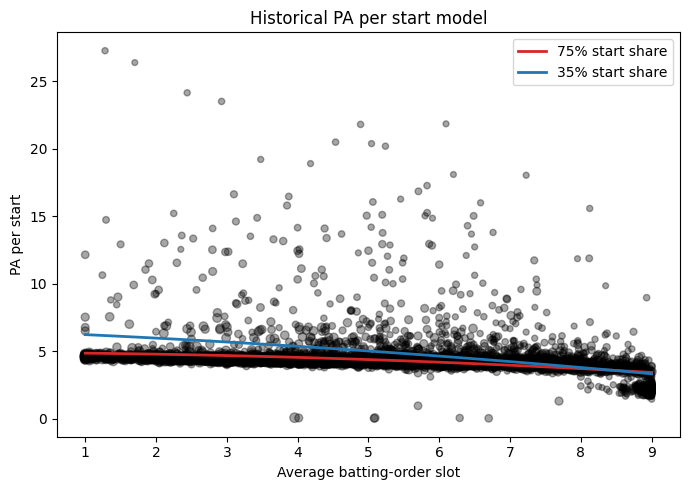

In [11]:
print(f"Training rows: {len(pa_model['train'])}")
print(f"Weighted residual sigma, PA/start: {pa_model['sigma']:.3f}")
plot_pa_per_start_fit(pa_model)

In [12]:
validation = holdout_year_validation(model_data)
validation

,year,group,n_players,mae,rmse,bias
0,2014,all,522,37.549765,67.779493,-5.872271
1,2014,regulars_50_starts,330,33.009205,51.372774,1.955458
2,2014,regulars_100_starts,182,23.045688,29.071858,-1.471212
3,2015,all,518,42.880211,77.499275,-9.502850
4,2015,regulars_50_starts,326,37.078670,68.058910,0.596719
5,2015,regulars_100_starts,184,26.043644,53.168604,1.744848
6,2016,all,513,35.705507,62.299611,-5.467907
7,2016,regulars_50_starts,328,32.104630,49.793024,0.876367
8,2016,regulars_100_starts,181,25.194654,31.745363,-8.089952
9,2017,all,515,38.674529,69.428098,-8.899651


,mae,rmse,bias
group,,,
all,32.745645,54.177315,0.242621
regulars_100_starts,25.287443,34.220849,-2.090614
regulars_50_starts,30.394632,45.897042,3.417553


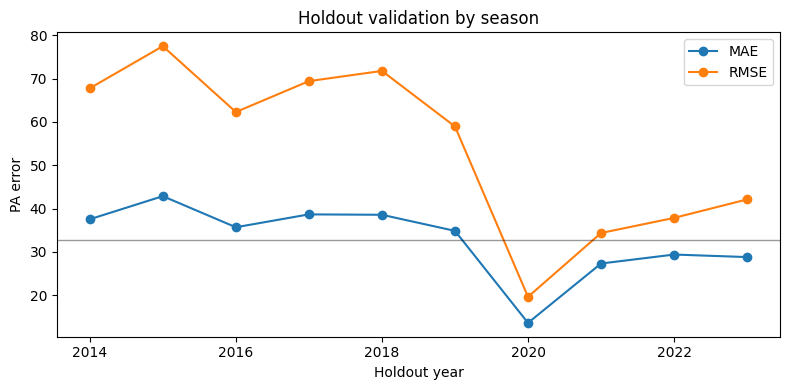

In [13]:
plot_holdout_validation(validation)
validation.groupby('group')[['mae', 'rmse', 'bias']].mean()

In [14]:
current_order = read_batting_order_summary(TARGET_YEAR)
current_order.sort_values(['team', 'starts'], ascending=[True, False]).head(20)

,year,player,player_display,player_key,team,avg_slot,starts,teamgames,start_share
55,2026,Max Muncy,Max Muncy,max muncy,ATH,6.06,114,85,1.341176
49,2026,Nick Kurtz,Nick Kurtz,nick kurtz,ATH,1.82,83,85,0.976471
51,2026,Tyler Soderstrom,Tyler Soderstrom,tyler soderstrom,ATH,4.05,78,85,0.917647
50,2026,Shea Langeliers,Shea Langeliers,shea langeliers,ATH,2.27,77,85,0.905882
56,2026,Jeff McNeil,Jeff McNeil,jeff mcneil,ATH,7.40,68,85,0.800000
62,2026,Zack Gelof,Zack Gelof,zack gelof,ATH,6.62,55,85,0.647059
53,2026,Jacob Wilson,Jacob Wilson,jacob wilson,ATH,4.16,50,85,0.588235
54,2026,Lawrence Butler,Lawrence Butler,lawrence butler,ATH,6.44,50,85,0.588235
58,2026,Carlos Cortes,Carlos Cortes,carlos cortes,ATH,4.10,49,85,0.576471
52,2026,Brent Rooker,Brent Rooker,brent rooker,ATH,3.85,47,85,0.552941


In [15]:
pa_forecast = forecast_current_year_pa(current_order, pa_model)
pa_forecast.head(40)

,team,player,avg_slot,starts_so_far,team_games_so_far,start_share_so_far,pa_per_start_model,projected_starts_p10,projected_starts_p50,projected_starts_p90,projected_pa_p10,projected_pa_p50,projected_pa_p90,projected_remaining_pa_p50
0,TB,Junior Caminero,2.86,81,81,1.000000,4.043359,158.0,161.0,162.0,502.181155,632.160153,716.772407,304.648071
1,NYM,Bo Bichette,2.18,85,85,1.000000,4.036342,158.0,161.0,162.0,501.928396,631.676894,714.850814,288.587806
2,PHI,Bryce Harper,2.95,84,85,0.988235,4.073103,156.0,159.0,161.0,502.759761,631.640123,714.492852,289.499469
3,ATL,Matt Olson,3.26,82,82,1.000000,4.041037,158.0,161.0,162.0,500.929958,631.207422,714.467592,299.842348
4,STL,Ivan Herrera,2.00,81,81,1.000000,4.032174,157.0,161.0,162.0,502.020069,630.636466,715.158413,304.030380
5,BAL,Pete Alonso,3.60,86,86,1.000000,4.035308,158.0,161.0,162.0,499.560133,630.434512,714.777087,283.398013
6,SF,Rafael Devers,3.62,84,84,1.000000,4.034864,158.0,161.0,162.0,501.197109,629.992732,714.391656,291.064188
7,ATL,Ozzie Albies,3.79,82,82,1.000000,4.030603,158.0,161.0,162.0,498.766053,629.790351,714.063655,299.280893
8,SEA,Julio Rodriguez,2.53,85,86,0.988372,4.073432,156.0,159.0,161.0,502.197847,629.595211,713.216680,283.353507
9,BAL,Gunnar Henderson,1.71,85,86,0.988372,4.059572,156.0,159.0,161.0,501.603041,627.828078,713.679066,282.764450


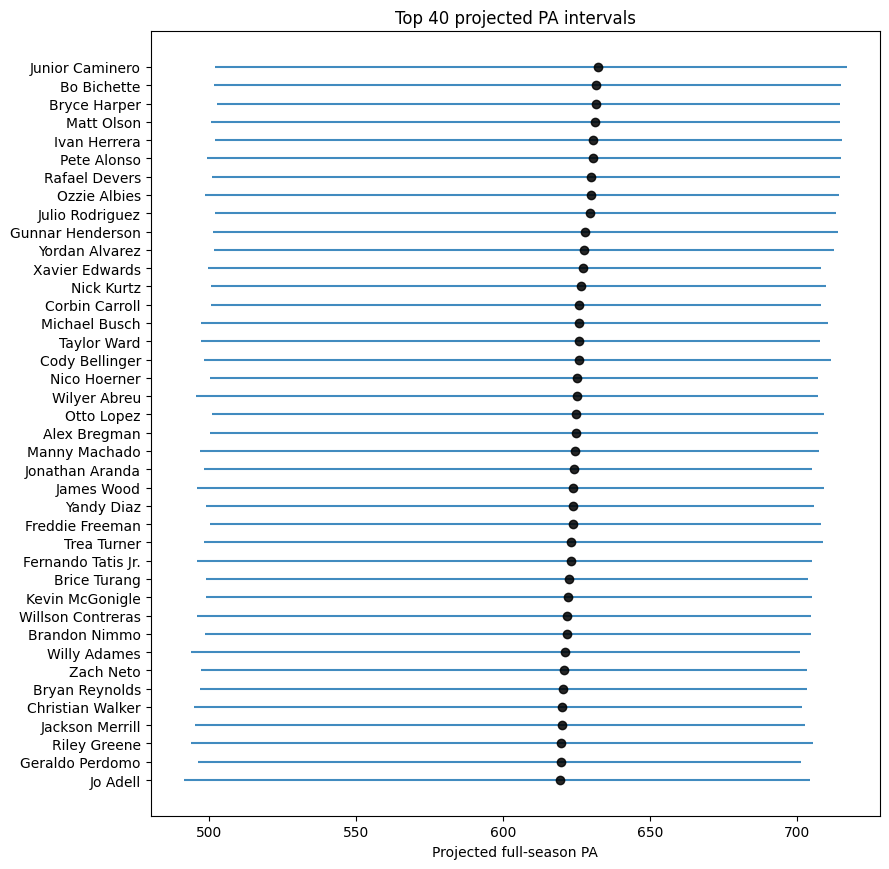

In [16]:
plot_forecast_intervals(pa_forecast, top_n=40)

In [17]:
PLAYER = 'Mike Trout'
player_forecast = pa_forecast[pa_forecast['player'].str.casefold() == PLAYER.casefold()]
player_forecast

,team,player,avg_slot,starts_so_far,team_games_so_far,start_share_so_far,pa_per_start_model,projected_starts_p10,projected_starts_p50,projected_starts_p90,projected_pa_p10,projected_pa_p50,projected_pa_p90,projected_remaining_pa_p50
76,LAA,Mike Trout,2.0,74,86,0.860465,4.447306,132.0,138.0,143.0,487.5231,597.818721,679.903439,268.718098


In [18]:
# Optional export for downstream use.
# pa_forecast.to_csv(f'{TARGET_YEAR}-pa-forecast-model.csv', index=False)

## Model Notes And Next Steps

- `starts` are lineup starts from the batting-order scraper, not all games appeared. The PA model therefore predicts PA per lineup start.
- Rows with impossible `starts > teamgames` are filtered out; these are usually same-name collisions in aggregate summaries.
- The beta-binomial start model treats observed starts through current team games as the role signal and shrinks it with a weak `Beta(2, 2)` prior.
- Forecast intervals include uncertainty in future starts and PA per start, but they do not yet include injury news, transactions, projected team context, or manual depth-chart assumptions.
- The holdout validation uses full-season lineup starts to test the PA-per-start component. A stronger backtest would replay each season from partial checkpoints: April 30, May 31, June 30, etc.
- The next major upgrade is to blend preseason/depth-chart priors with the in-season beta-binomial role model, so a player with 20 early starts is not treated identically to an established everyday player with the same early start rate.